# Bike Availability Modeling



# Part 1 Feature pairs check


Loaded: final_merged_data.csv.gz
Shape after filter: (298946, 25)
Top 20 by |correlation|:
bikes_1d_mean           0.720048
bikes_same_slot_mean    0.655850
capacity                0.205051
lon                     0.124585
humidity                0.011577
day                     0.003829
weekend                 0.003756
temp                    0.002011
minute                 -0.000847
weekday                -0.000935
number                 -0.001356
pressure               -0.002130
hour                   -0.004754
lat                    -0.137569
num_docks_available    -0.717459
stno                         NaN
year                         NaN
month                        NaN
Name: num_bikes_available, dtype: float64
bikes_1d_mean corr = 0.720048
bikes_same_slot_mean corr = 0.655850


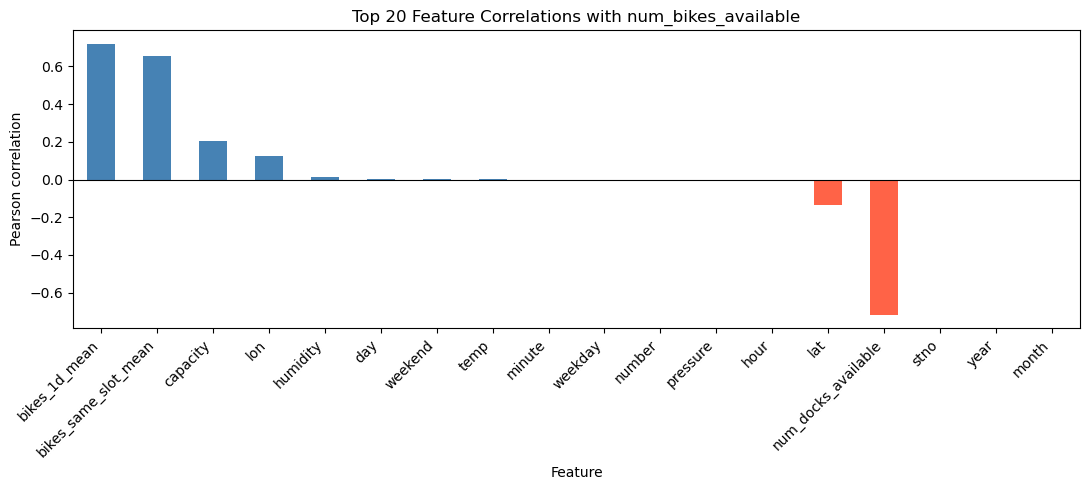

In [ ]:
# Part 1: Feature Pair Check【中文详细注释版】
# 目标：
# - 读取原始数据；
# - 构造最小天气/时间特征（保留 temp / humidity / pressure）；
# - 在特征检查阶段加入 lag：bikes_1d_mean、bikes_same_slot_mean；
# - 删除冗余天气原始列；
# - 快速查看与目标变量的相关性 Top20。

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 每 10 分钟一条记录：1 天 144 条，1 周 1008 条
INTERVALS_PER_DAY = 144
INTERVALS_PER_WEEK = 1008

# 1) 读取数据（兼容项目根目录 / machine_learning 子目录）
candidates = [Path('final_merged_data.csv.gz'), Path('machine_learning/final_merged_data.csv.gz')]
raw_path = next((x for x in candidates if x.exists()), None)
if raw_path is None:
    raise FileNotFoundError('Cannot find final_merged_data.csv.gz')
df_raw = pd.read_csv(raw_path)

# 2) 字段标准化：统一站点编号列名为 number（后续建模统一使用）
if 'number' not in df_raw.columns and 'station_id' in df_raw.columns:
    df_raw = df_raw.rename(columns={'station_id': 'number'})

# 3) 必需列检查：缺列时立即报错，避免后续隐式失败
required = [
    'max_air_temperature_celsius', 'min_air_temperature_celsius',
    'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa',
    'max_relative_humidity_percent', 'min_relative_humidity_percent',
    'day', 'num_bikes_available', 'last_reported', 'number','num_docks_available'
]
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}')

# 4) 构造轻量天气特征（保留 temp / pressure / humidity）
# errors='coerce'：异常字符转 NaN，防止类型错误中断流程
df_raw['temp'] = (
    pd.to_numeric(df_raw['max_air_temperature_celsius'], errors='coerce')
    + pd.to_numeric(df_raw['min_air_temperature_celsius'], errors='coerce')
) / 2

df_raw['pressure'] = (
    pd.to_numeric(df_raw['max_barometric_pressure_hpa'], errors='coerce')
    + pd.to_numeric(df_raw['min_barometric_pressure_hpa'], errors='coerce')
) / 2

# humidity 与 Part2 保持一致：二值化（均值 > 90 记为 1）
hum_avg = (
    pd.to_numeric(df_raw['max_relative_humidity_percent'], errors='coerce')
    + pd.to_numeric(df_raw['min_relative_humidity_percent'], errors='coerce')
) / 2
df_raw['humidity'] = (hum_avg > 90).astype(int)

# 5) 构造最小时间标签 weekday/weekend
# 说明：这里使用 day % 7 的近似写法，只用于轻量筛查，不是严格日历星期
day_num = pd.to_numeric(df_raw['day'], errors='coerce')
df_raw['weekday'] = day_num % 7
df_raw['weekend'] = df_raw['weekday'].isin([5, 6]).astype(int)

# 6) 先构造 lag 特征（防泄漏：shift(1) 后 rolling）
# 这样当前行不会用到当前时刻的 num_bikes_available。
df_raw['last_reported'] = pd.to_datetime(df_raw['last_reported'], errors='coerce')
df_raw['number'] = pd.to_numeric(df_raw['number'], errors='coerce')
df_raw['num_bikes_available'] = pd.to_numeric(df_raw['num_bikes_available'], errors='coerce')

lag_base = df_raw.dropna(subset=['last_reported', 'number', 'num_bikes_available']).copy()
# 记录原始行索引，后面计算完 lag 要按这个索引回写到 df_raw
lag_base['_orig_idx'] = lag_base.index
lag_base['number'] = lag_base['number'].astype(int)
lag_base = lag_base.sort_values(['number', 'last_reported']).reset_index(drop=True)

g = lag_base.groupby('number')['num_bikes_available']
lag_base['bikes_1d_mean'] = g.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_DAY, min_periods=INTERVALS_PER_DAY // 2).mean()
)
# 同时段历史均值：同站点+同星期几+同小时+同分钟（只用过去数据）
slot_hour = lag_base['last_reported'].dt.hour

# 仅按 number + hour 分组
lag_base['bikes_same_slot_mean'] = (
    lag_base.groupby(['number', slot_hour])['num_bikes_available']
            .transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
)

# 与 Part 2 保持一致：lag 缺失先用站点均值，再用全局均值
station_mean = lag_base.groupby('number')['num_bikes_available'].transform('mean')
global_mean = float(lag_base['num_bikes_available'].mean())
for c in ['bikes_1d_mean', 'bikes_same_slot_mean']:
    lag_base[c] = lag_base[c].fillna(station_mean).fillna(global_mean)

# 回写到 df_raw（按原始行索引对齐，避免错位）
df_raw.loc[lag_base['_orig_idx'], 'bikes_1d_mean'] = lag_base['bikes_1d_mean'].values
df_raw.loc[lag_base['_orig_idx'], 'bikes_same_slot_mean'] = lag_base['bikes_same_slot_mean'].values

# 7) 清理原始天气大列，仅保留 temp（降低冗余和噪声）
# 注意：这里不会删除 bikes_1d_mean / bikes_same_slot_mean。
weather_keywords = [
    'temperature', 'humidity', 'pressure', 'barometric', 'weather',
    'wind', 'rain', 'snow', 'soil', 'earth', 'grass', 'quality_indicator'
]
def is_raw_weather_col(col: str) -> bool:
    lc = col.lower()
    return any(k in lc for k in weather_keywords)

keep_weather = {'temp', 'pressure', 'humidity'}
drop_cols = [c for c in df_raw.columns if is_raw_weather_col(c) and c not in keep_weather]
df_model = df_raw.drop(columns=drop_cols, errors='ignore').copy()

# 8) 计算与目标变量的 Pearson 相关系数（仅数值列）
num_cols = df_model.select_dtypes(include=['number']).columns.tolist()
feature_cols = [c for c in num_cols if c != 'num_bikes_available']
corr = (
    df_model[feature_cols + ['num_bikes_available']]
    .corr(numeric_only=True)['num_bikes_available']
    .drop('num_bikes_available')
)

# 9) 提取绝对值 Top20，并按原符号排序，便于观察正负方向
top20 = corr.abs().sort_values(ascending=False).head(20).index
plot_data = corr.loc[top20].sort_values(ascending=False)

print(f'Loaded: {raw_path}')
print(f'Shape after filter: {df_model.shape}')
print('Top 20 by |correlation|:')
print(plot_data)

# 确认 lag 已加入 Part1 特征检查
for lag_col in ['bikes_1d_mean', 'bikes_same_slot_mean']:
    if lag_col in corr.index:
        print(f'{lag_col} corr = {corr[lag_col]:.6f}')
    else:
        print(f'{lag_col} not found in numeric corr columns')

# 10) 可视化：正相关蓝色，负相关红色
plt.figure(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in plot_data.values]
plot_data.plot(kind='bar', color=colors)
plt.title('Top 20 Feature Correlations with num_bikes_available')
plt.xlabel('Feature')
plt.ylabel('Pearson correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()







# Part 1 conclution:
 从相关性上,需要保留的特征为:
- 日期:day,hour,minute,
- 天气:temp,pressure,humidity
- 地理:lon,lat,number
- 车辆数据:bikes_1d_mean,bikes_same_slot_mean,capacity
- Ps:num_bikes_available 和num_docks_available是互补的,所以特征不保留,防止数据泄露造成过拟合.


## Part 2: Data Cleaning
Load raw data, build time/weather/lag features, and produce `df_clean`.


In [2]:
import pandas as pd
from pathlib import Path

# Part 2: Data Cleaning
# 目标：
# - 基础清洗（时间/编号/目标字段）；
# - 构造简化天气特征 temp/pressure/humidity；
# - 构造防泄漏历史特征（bikes_1d_mean + bikes_same_slot_mean）；
# - 输出 df_clean、features、target、data_cleaned.csv。

# 每 10 分钟一条记录：1 天 144 条
INTERVALS_PER_DAY = 144

# 1) 读取数据（兼容两种运行目录）
candidates = [Path('final_merged_data.csv.gz'), Path('machine_learning/final_merged_data.csv.gz')]
raw_path = next((x for x in candidates if x.exists()), None)
if raw_path is None:
    raise FileNotFoundError('Cannot find final_merged_data.csv.gz')
df = pd.read_csv(raw_path)

# 2) 统一站点编号列名
if 'number' not in df.columns and 'station_id' in df.columns:
    df = df.rename(columns={'station_id': 'number'})

# 3) 基础必需列检查
required = ['last_reported', 'number', 'num_bikes_available', 'day', 'hour', 'minute', 'lon', 'lat']
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}')

# 4) 类型转换：非法值转缺失，随后统一删除
df['last_reported'] = pd.to_datetime(df['last_reported'], errors='coerce')
for c in ['number', 'num_bikes_available', 'day', 'hour', 'minute', 'lon', 'lat']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=required).copy()
df[['number', 'day', 'hour', 'minute']] = df[['number', 'day', 'hour', 'minute']].astype(int)

# 模型字段标准化：
# - 目标列使用 available_bikes（由原始 num_bikes_available 转换）
# - 地理列使用 lng（由原始 lon 转换）和 lat
df['available_bikes'] = df['num_bikes_available']
df['lng'] = df['lon']

# 5) 天气列检查并构造紧凑天气特征
weather_req = [
    'max_air_temperature_celsius', 'min_air_temperature_celsius',
    'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa',
    'max_relative_humidity_percent', 'min_relative_humidity_percent',
]
missing_weather = [c for c in weather_req if c not in df.columns]
if missing_weather:
    raise KeyError(f'Missing required weather columns: {missing_weather}')

df['temp'] = (df['max_air_temperature_celsius'] + df['min_air_temperature_celsius']) / 2
df['pressure'] = (df['max_barometric_pressure_hpa'] + df['min_barometric_pressure_hpa']) / 2
df['humidity'] = (((df['max_relative_humidity_percent'] + df['min_relative_humidity_percent']) / 2) > 90).astype(int)

# 6) 防泄漏历史特征
# 先按站点+时间排序，确保所有滚动/历史统计顺序正确
df = df.sort_values(['number', 'last_reported']).reset_index(drop=True)

g = df.groupby('number')['num_bikes_available']

# (a) 1天移动均值（只看过去，shift(1) 防泄漏）
df['bikes_1d_mean'] = g.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_DAY, min_periods=INTERVALS_PER_DAY // 2).mean()
)

# (b) 同时段历史均值（替代 bikes_7d_mean）
# 定义：同站点 + 同星期几 + 同小时 + 同分钟，在“当前行之前”历史记录的平均值
slot_hour = df['last_reported'].dt.hour
slot_minute = df['last_reported'].dt.minute

# 仅按 number + hour + minute 分组（不使用 weekday）
df['bikes_same_slot_mean'] = (
    df.groupby(['number', slot_hour, slot_minute])['num_bikes_available']
      .transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
)

# 7) 缺失填充：先站点均值，再全局均值
station_mean = df.groupby('number')['num_bikes_available'].transform('mean')
global_mean = float(df['num_bikes_available'].mean())
for c in ['bikes_1d_mean', 'bikes_same_slot_mean']:
    df[c] = df[c].fillna(station_mean).fillna(global_mean)

# 8) 最小可用特征集合（与后续模型 cell 对齐）
features = [
    'number', 'capacity', 'day', 'hour', 'minute',
    'temp', 'pressure', 'humidity',
    'lng', 'lat',
    'bikes_1d_mean', 
    'bikes_same_slot_mean',
]
target = 'available_bikes'

missing_final = [c for c in features + [target] if c not in df.columns]
if missing_final:
    raise KeyError(f'Missing required final columns: {missing_final}')

# 9) 生成 df_clean 并导出 CSV
df_clean = (
    df[features + [target, 'last_reported']]
    .dropna()
    .sort_values('last_reported')
    .reset_index(drop=True)
)
df_clean[features + [target]].to_csv(raw_path.parent / 'data_cleaned.csv', index=False)

print(f'Loaded: {raw_path}')
print(f'Cleaned shape: {df_clean.shape}')
print(f'Saved: {raw_path.parent / "data_cleaned.csv"}')
display(df_clean.head(3))





Loaded: final_merged_data.csv.gz
Cleaned shape: (298946, 14)
Saved: data_cleaned.csv


,number,capacity,day,hour,minute,temp,pressure,humidity,lng,lat,bikes_1d_mean,bikes_same_slot_mean,available_bikes,last_reported
0,31,20,1,0,10,13.955,1002.41,0,-6.265125,53.350930,10.652259,10.652259,3,2024-12-01 00:10:00
1,13,30,1,0,10,13.955,1002.41,0,-6.252825,53.336075,12.959508,12.959508,0,2024-12-01 00:10:00
2,4,20,1,0,10,13.955,1002.41,0,-6.272976,53.346874,10.550703,10.550703,11,2024-12-01 00:10:00


# Part 3: Model Training
Train linear regression using `df_clean`:
- Use one-hot encoding for `number`
- Use time-ordered 70/30 split

## 3.1. Liner Regression with Lag Features

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path



X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

models = {
    'Linear Regression': LinearRegression(),
}

results = []

for name, model in models.items():
    print(f"Model training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
    })

    print(f"  MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

results_df = pd.DataFrame(results).set_index('model')
display(results_df)

# 保存模型
model_dir = Path('machine_learning') if Path('machine_learning').exists() else Path('.')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'linear_regression_lag_model.joblib'
meta_path = model_dir / 'linear_regression_lag_model_meta.joblib'

joblib.dump(model, model_path)
joblib.dump({'features': features, 'target': target}, meta_path)

print(f'Saved model: {model_path}')
print(f'Saved meta : {meta_path}')


Model training Linear Regression...
  MAE: 4.9487 | RMSE: 6.5073 | R²: 0.5569


,MAE,RMSE,R²
model,,,
Linear Regression,4.9487,6.5073,0.5569


Saved model: linear_regression_lag_model.joblib
Saved meta : linear_regression_lag_model_meta.joblib


## 3.2.SVR
## 3.3.Random 
## 4.1.Forest 
## 5.1.Ridge 
## 6.1.Regression
## 7.1.Decision Tree

# Part 4: Analyse model performance
- 1.Linear Regression
- 2.SVR
- 3.Random 
- 4.Forest 
- 5.Ridge 
- 6.Regression
- 7.Decision Tree

## 4.1. Linear Regression
This model performs well in short-term forecasts (Test R² ≈ 0.69, MAE ≈ 3.7), but the lower cross-validation results (CV R² ≈ 0.545) indicate that its generalization across time windows remains limited.
Performance improvements rely primarily on lagged features rather than static weather or time variables which shows on data feature pair check part.

# Part 5 :Prediction applied on Flask API
### modification on APP.py to load the model and make prediction